Import libraries

In [41]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score


In [42]:
import os
os.listdir()

['.config',
 'housing (3).csv',
 'Housing.ipynb',
 'housing.csv',
 'housing (2).csv',
 'housing (1).csv',
 'housing-price-prediction-linear-regression.ipynb',
 'Housing (1).ipynb',
 'sample_data']

In [47]:
new_df = pd.read_csv('housing (2).csv', skiprows=15, on_bad_lines='skip', engine='python')

In [48]:
from google.colab import files
uploaded=files.upload()

Saving Housing new.csv to Housing new.csv


In [50]:
import pandas as pd
df=pd.read_csv('Housing new.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


One Hot encoding for categorical variables

In [52]:
df_encoded=pd.get_dummies(df,drop_first=True)

Featured-target split

In [55]:
x=df_encoded.drop('price',axis=1)
y=df_encoded['price']

Train-test split


In [57]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=4)

Model Training


In [59]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

Predictions

In [60]:
y_pred=model.predict(x_test)


Evaluation


In [61]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [63]:
print(f'Mean Squared Error:{mse}')
print(f'R-Squared score:{r2}')

Mean Squared Error:1090249641230.1273
R-Squared score:0.6585429213347458


Visualization: Actual vs Predicted

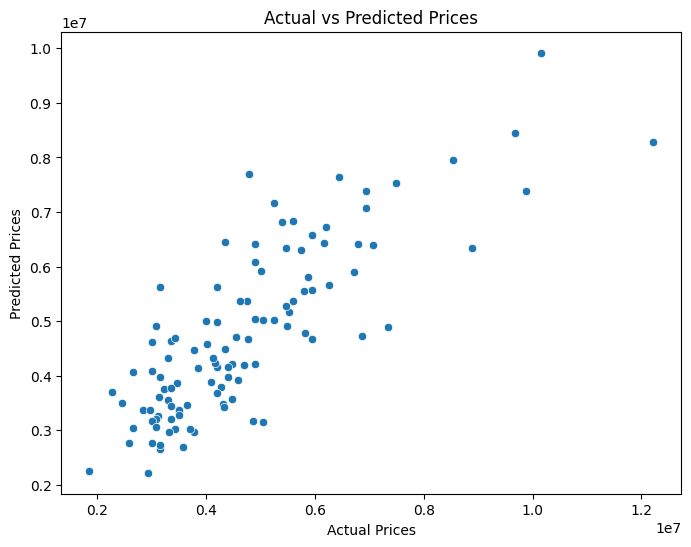

In [64]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()